# Connectivity over time and button presses

- the goal of this script is to find a relationship between button presses and connectivity over time
- The number of button presses for ALL runs are found via: get_bpress_connxbpress.py
- The difference in correlation matrices from run 1 to run 4 for internal and external are found via: collect-sub-conn.py

In [167]:
# imports
import numpy as np
import os

from nilearn import datasets, plotting
from brainiak.isc import squareform_isfc
from utils_anal import resample_atlas, get_network_labels
from matplotlib import pyplot as plt
from statsmodels.stats.multitest import multipletests

import pandas as pd
import seaborn as sns




In [168]:
# paths #
top_dir = '/jukebox/graziano/coolCatIsaac/mei'
data_dir = top_dir + "/data"
work_dir = data_dir + '/work'
behav_dir = top_dir + '/data/work/button_press_counts'
preproc_dir = work_dir + '/preproc'
schaef_dir = '/jukebox/graziano/coolCatIsaac/mei/data/work/schaefer_atlas'
wsfc_dir = work_dir + '/wsfc'

In [15]:
## load 

In [52]:
## Load button presses output
n = 'all_subjects_button_presses.npy'
bpress = np.load(f'{behav_dir}/{n}', allow_pickle=True).item()
## load wsfc dictionary
n = 'ext_int_sub_cor_mat.npy'
wsfc_c = np.load(f'{wsfc_dir}/{n}', allow_pickle=True).item()

In [53]:
bpress

{'sub-002': {'External': 39, 'Internal': 31},
 'sub-003': {'External': 3, 'Internal': 68},
 'sub-004': {'External': 54, 'Internal': 45},
 'sub-005': {'External': 24, 'Internal': 36},
 'sub-006': {'External': 20, 'Internal': 28},
 'sub-007': {'External': 34, 'Internal': 93},
 'sub-008': {'External': 20, 'Internal': 21},
 'sub-009': {'External': 38, 'Internal': 53},
 'sub-010': {'External': 35, 'Internal': 55},
 'sub-012': {'External': 17, 'Internal': 41},
 'sub-013': {'External': 58, 'Internal': 49},
 'sub-014': {'External': 0, 'Internal': 0},
 'sub-015': {'External': 121, 'Internal': 192},
 'sub-016': {'External': 27, 'Internal': 43},
 'sub-018': {'External': 30, 'Internal': 71},
 'sub-019': {'External': 92, 'Internal': 101},
 'sub-020': {'External': 0, 'Internal': 0},
 'sub-021': {'External': 23, 'Internal': 25},
 'sub-022': {'External': 66, 'Internal': 89},
 'sub-023': {'External': 19, 'Internal': 93},
 'sub-024': {'External': 18, 'Internal': 38},
 'sub-025': {'External': 40, 'Intern

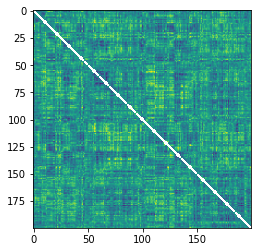

In [58]:
plt.imshow(wsfc_c['sub-003']['external'])

## ROIS

In [31]:
##### Variables for the atlas ### 

num_parc = 200 ## CHANGE ME
num_net= 17 ## CHANGE ME


###### ROI Loading ### 
# LOAD ATLAS #
## fetch dataset
dataset = datasets.fetch_atlas_schaefer_2018(n_rois=num_parc, yeo_networks = num_net)

# get nii dataset location
atlas_filename = dataset.maps
## get *ROI* atlas labels
labels = dataset.labels

# resample loaded atlas 
atlas_nii, atlas_img = resample_atlas(atlas_filename, '')

# Load in network labels for each parcell, parcel UNspecific network labels, and the middle parcel within each network
networks, network_labels, network_idxs = get_network_labels(num_parc, num_net)

count parc:201
shape of atlas nii object (78, 93, 65)
two networks: ['L VisCent', 'L VisPeri'] 
 total nets: 34


# start anal

In [157]:
'''
LOAD:
6vid_wsfc_external_run1-run4.npy
6vid_wsfc_external_run4-run1_fish.npy
6vid_wsfc_internal_run4-run1_fish.npy
6vid_wsfc_run1_ext-int_fish.npy
6vid_wsfc_run1_int-ext_fish.npy
6vid_wsfc_run4_ext-int_fish.npy

6vid_wsfc_run1-4-AV_ext+int_fish.npy
6vid_wsfc_run4_ext-int_fish_TWO_mats.npy
'''

anal_sav_name = '6vid_wsfc_internal_run4-run1_fish.npy'

## get sigs

FDR corrected significant values: 247


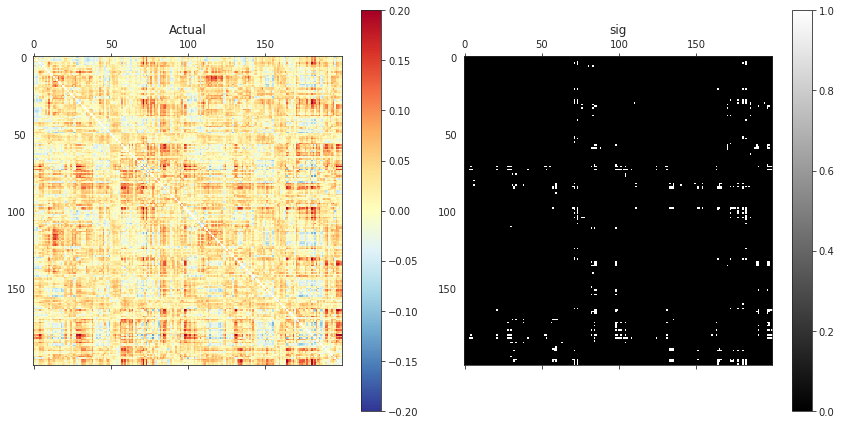

In [158]:
wsfc_info = np.load(os.path.join(wsfc_dir, anal_sav_name), allow_pickle=True).item()
actual_cors_across_movs = wsfc_info['actual_cors_across_movs']
perms_across_movs = wsfc_info['perms_across_movs']
d_shape = 200

## Get significance ##
pval = 0.05

cat_wsfc_av = np.mean(np.stack(actual_cors_across_movs), axis=0)
perm_mat_av = np.mean(np.stack(perms_across_movs), axis=0)

# Two-sided p-values: Compare both lower and upper tails
sig_vals = [
    2 * min(
        (np.sum(val < perm_mat_av[:, idx])) / perm_mat_av.shape[0],
        (np.sum(val > perm_mat_av[:, idx])) / perm_mat_av.shape[0]
    )
    for idx, val in enumerate(cat_wsfc_av)
]

# Transform back into matrix
off_diag = np.array(sig_vals[:-d_shape])
diag = np.array(sig_vals[-d_shape:])
sig_val_mat = squareform_isfc(off_diag, diag)

# Binary significant values
sig_val_bin = [1 if val < pval else 0 for val in sig_vals]

# Run FDR correction
rejected, p_corrected, _, _ = multipletests(off_diag, alpha=0.05, method='fdr_bh')

# Output results
print(f'FDR corrected significant values: {np.sum(rejected)}')

vmin=-.2
vmax=.2
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

## get the averaged actual corr mat ##
off_diag = np.array(cat_wsfc_av[:-d_shape])
diag = np.array(cat_wsfc_av[-d_shape:])
actual_dif_mat = squareform_isfc(off_diag, diag)

image1 = axs[0].matshow(actual_dif_mat, vmin=vmin, vmax=vmax, cmap='RdYlBu_r')
axs[0].set_title(f'Actual')
cbar1 = plt.colorbar(image1, ax=axs[0])


# Get the significant values from calculation above #
off_diag = np.array(sig_val_bin) # **** ONE SAMPLE T
off_diag = np.array(rejected * 1) # **** ONE SAMPLE T
diag = np.zeros((d_shape))
sig_mat_r = squareform_isfc(off_diag, diag)
image2 = axs[1].matshow(sig_mat_r, cmap='binary_r')
axs[1].set_title('sig')
cbar1 = plt.colorbar(image2, ax=axs[1])

# Adjust spacing between subplots and colorbars
plt.tight_layout()
plt.show()


## get sig indices by connection

- In the below cells we extract correlations from targeted networks (that were significant)

In [159]:

# networks to search for
substr_1 = b'LH_DorsAttnA'#b'LH_DorsAttnA', b'LH_ContA' , b'RH_ContA'
substr_2 = b'RH_ContC'#b'RH_ContC', b'LH_DefaultA' b'LH_DefaultB'

# Find indices for the substrings
indices_1 = [i for i, x in enumerate(labels) if substr_1 in x]
indices_2 = [i for i, x in enumerate(labels) if substr_2 in x]

print(f"Indices for {substr_1}:", indices_1)
print(f"Indices for {substr_2}:", indices_2)


Indices for b'LH_DorsAttnA': [28, 29, 30, 31, 32, 33]
Indices for b'RH_ContC': [180, 181, 182]


In [160]:
# Find all pairs between the two networks that were SIGNIFICANT and extract the correlation
row_indices, col_indices = np.where(sig_mat_r == 1)
indices = list(zip(row_indices, col_indices))


In [161]:
# Find all matching pairs and extract the 
matching_combinations = []
extracted_values = []


# Iterate through all combinations
for row in indices_1:
    for col in indices_2:
        # Check if the pair (row, col) is in the matching pairs
        if (row, col) in indices:
            matching_combinations.append((row, col))
            extracted_values.append(s_mat[row, col])  # Extract value from the matrix


# Print the result
print("Matching combinations:", matching_combinations)

Matching combinations: [(28, 180), (28, 182), (29, 180), (29, 182), (30, 180), (30, 182)]


In [162]:
len(matching_combinations)

6

## PLOT

### average for the network

In [165]:
c = 'internal' ## which frmi data to extract

KeyError: sub-017 or Internal not found in conn or bpress
KeyError: sub-020 or Internal not found in conn or bpress


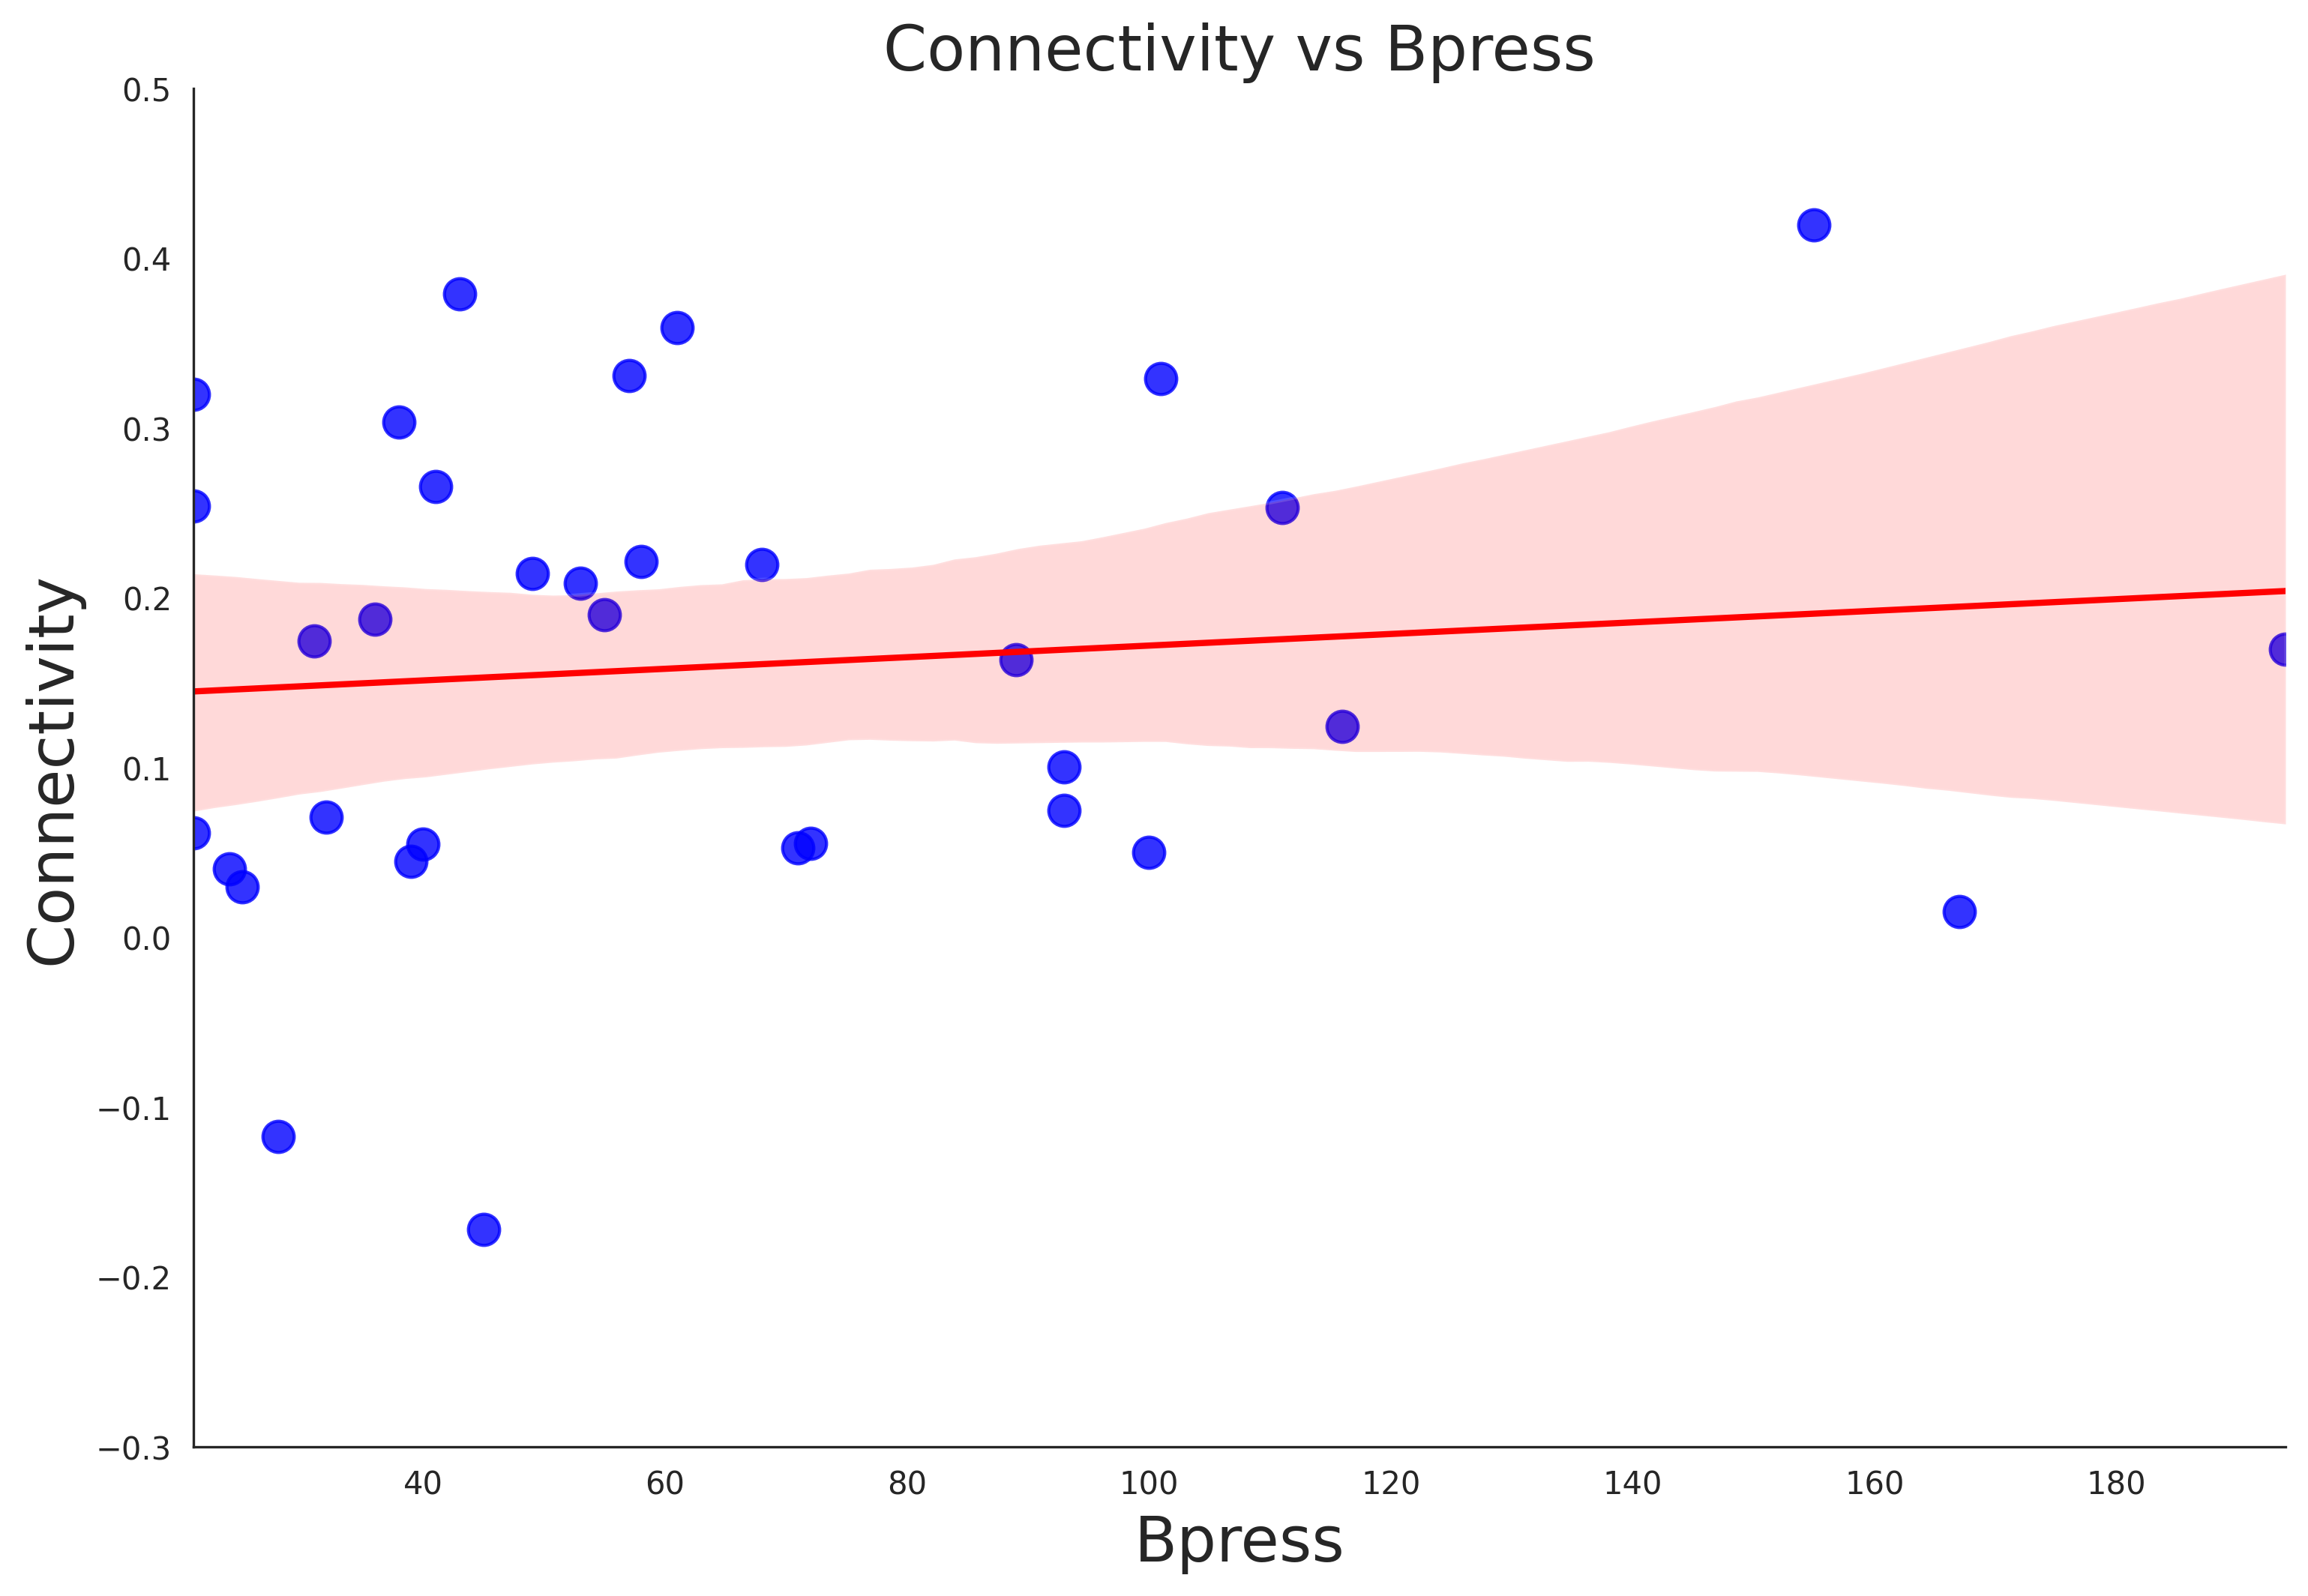

In [166]:
# Initialize results dictionary to store connectivity and bpress values
results = {'conn': [], 'bpress': []}

# Iterate over subjects (assuming `wsfc_c` is a dictionary with subjects as keys)
for s in wsfc_c:
    # Check if the connectivity data is available for the given condition
    try:
        s_mat = wsfc_c[s][c]  # has connectivity data
        bpress_value = bpress[s][c.capitalize()]  # has button press data
    except KeyError:
        print(f"KeyError: {s} or {c.capitalize()} not found in conn or bpress")
        continue

    # Extract the connectivity matrix for the subject
    extracted_values = []
    for row in indices_1:
        for col in indices_2:
            if (row, col) in indices:
                extracted_values.append(s_mat[row, col])
    
    # Only append the first extracted value for the subject
    if extracted_values:  # Ensure there are extracted values
        results['conn'].append(np.mean(extracted_values))  # Only append the first value
    
    # Append the corresponding bpress value for the subject
    results['bpress'].append(bpress_value)

# Convert the results to a DataFrame for easy plotting
df = pd.DataFrame(results)

# Set Seaborn style
sns.set_style('white')

# Plot using seaborn with a line of fit
plt.figure(figsize=(12, 8), dpi=300)

# Scatterplot with line of fit
sns.regplot(data=df, x='bpress', y='conn', scatter_kws={'s': 100, 'color': 'blue'}, line_kws={'color': 'red', 'lw': 2})

# Set y-axis limits
plt.ylim(-0.3, 0.5)

# Title and labels
plt.title('Connectivity vs Bpress', fontsize=20)
plt.xlabel('Bpress', fontsize=20)
plt.ylabel('Connectivity', fontsize=20)

# Remove spines for cleaner look
sns.despine()

plt.show()


### choose a regions within a network - net_id

In [ ]:
# Initialize results dictionary to store connectivity and bpress values
results = {'conn': [], 'bpress': []}
con_id = 8 ## which con_id to extract from the net

# Iterate over subjects (assuming `wsfc_c` is a dictionary with subjects as keys)
for s in wsfc_c:
    # Check if the connectivity data is available for the given condition
    try:
        s_mat = wsfc_c[s][c]  # has connectivity data
        bpress_value = bpress[s][c.capitalize()]  # has button press data
    except KeyError:
        print(f"KeyError: {s} or {c.capitalize()} not found in conn or bpress")
        continue

    # Extract the connectivity matrix for the subject
    extracted_values = []
    for row in indices_1:
        for col in indices_2:
            if (row, col) in indices:
                extracted_values.append(s_mat[row, col])
    
    # Only append the first extracted value for the subject
    if extracted_values:  # Ensure there are extracted values
        results['conn'].append(extracted_values[con_id])  # Only append the first value
    
    # Append the corresponding bpress value for the subject
    results['bpress'].append(bpress_value)

# Convert the results to a DataFrame for easy plotting
df = pd.DataFrame(results)

# Set Seaborn style
sns.set_style('white')

# Plot using seaborn with a line of fit
plt.figure(figsize=(12, 8))

# Scatterplot with line of fit
sns.regplot(data=df, x='bpress', y='conn', scatter_kws={'s': 100, 'color': 'blue'}, line_kws={'color': 'red', 'lw': 2})

# Title and labels
plt.title('Connectivity vs Bpress', fontsize=20)
plt.xlabel('Bpress', fontsize=20)
plt.ylabel('Connectivity', fontsize=20)

# Remove spines for cleaner look
sns.despine()

plt.show()


### plot all net_ids

KeyError: sub-017 or External not found in conn or bpress
KeyError: sub-020 or External not found in conn or bpress
KeyError: sub-017 or External not found in conn or bpress
KeyError: sub-020 or External not found in conn or bpress
KeyError: sub-017 or External not found in conn or bpress
KeyError: sub-020 or External not found in conn or bpress
KeyError: sub-017 or External not found in conn or bpress
KeyError: sub-020 or External not found in conn or bpress
KeyError: sub-017 or External not found in conn or bpress
KeyError: sub-020 or External not found in conn or bpress
KeyError: sub-017 or External not found in conn or bpress
KeyError: sub-020 or External not found in conn or bpress
KeyError: sub-017 or External not found in conn or bpress
KeyError: sub-020 or External not found in conn or bpress
KeyError: sub-017 or External not found in conn or bpress
KeyError: sub-020 or External not found in conn or bpress
KeyError: sub-017 or External not found in conn or bpress
KeyError: sub-

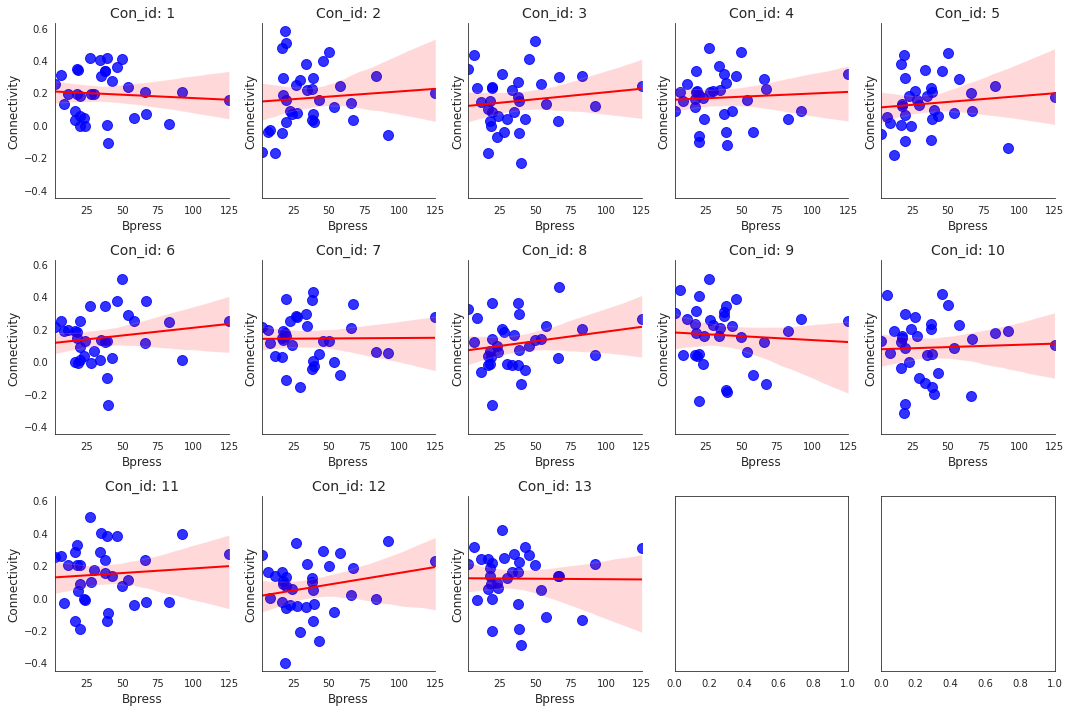

In [156]:
# Initialize results dictionary to store connectivity and bpress values
results = {'conn': [], 'bpress': []}

# Set Seaborn style
sns.set_style('white')

# Create subplots with 3 rows and 5 columns (13 total subplots)
fig, axes = plt.subplots(3, 5, figsize=(15, 10), sharey=True)
axes = axes.flatten()  # Flatten the axes array to make indexing easier

# Iterate over the con_id values (assuming 13 different conditions)
for con_id in range(len(matching_combinations)):
    con_results = {'conn': [], 'bpress': []}
    
    # Iterate over subjects (assuming `wsfc_c` is a dictionary with subjects as keys)
    for s in wsfc_c:
        # Check if the connectivity data is available for the given condition
        try:
            s_mat = wsfc_c[s][c]  # has connectivity data
            bpress_value = bpress[s][c.capitalize()]  # has button press data
        except KeyError:
            print(f"KeyError: {s} or {c.capitalize()} not found in conn or bpress")
            continue

        # Extract the connectivity matrix for the subject
        extracted_values = []
        for row in indices_1:
            for col in indices_2:
                if (row, col) in indices:
                    extracted_values.append(s_mat[row, col])
        
        # Only append the value for the current con_id
        if extracted_values:
            con_results['conn'].append(extracted_values[con_id])
        
        # Append the corresponding bpress value for the subject
        con_results['bpress'].append(bpress_value)
    
    # Convert the results to a DataFrame for easy plotting
    df = pd.DataFrame(con_results)
    
    # Plot using seaborn with a line of fit
    ax = axes[con_id]
    sns.regplot(data=df, x='bpress', y='conn', scatter_kws={'s': 100, 'color': 'blue'}, line_kws={'color': 'red', 'lw': 2}, ax=ax)
    
    # Set the title and labels for the subplot
    ax.set_title(f'Con_id: {con_id + 1}', fontsize=14)
    ax.set_xlabel('Bpress', fontsize=12)
    ax.set_ylabel('Connectivity', fontsize=12)
    
    # Remove spines for cleaner look
    sns.despine(ax=ax)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


KeyError: sub-017 or Internal not found in conn or bpress
KeyError: sub-020 or Internal not found in conn or bpress
KeyError: sub-017 or Internal not found in conn or bpress
KeyError: sub-020 or Internal not found in conn or bpress
KeyError: sub-017 or Internal not found in conn or bpress
KeyError: sub-020 or Internal not found in conn or bpress
KeyError: sub-017 or Internal not found in conn or bpress
KeyError: sub-020 or Internal not found in conn or bpress
KeyError: sub-017 or Internal not found in conn or bpress
KeyError: sub-020 or Internal not found in conn or bpress
KeyError: sub-017 or Internal not found in conn or bpress
KeyError: sub-020 or Internal not found in conn or bpress
KeyError: sub-017 or Internal not found in conn or bpress
KeyError: sub-020 or Internal not found in conn or bpress
KeyError: sub-017 or Internal not found in conn or bpress
KeyError: sub-020 or Internal not found in conn or bpress
KeyError: sub-017 or Internal not found in conn or bpress
KeyError: sub-

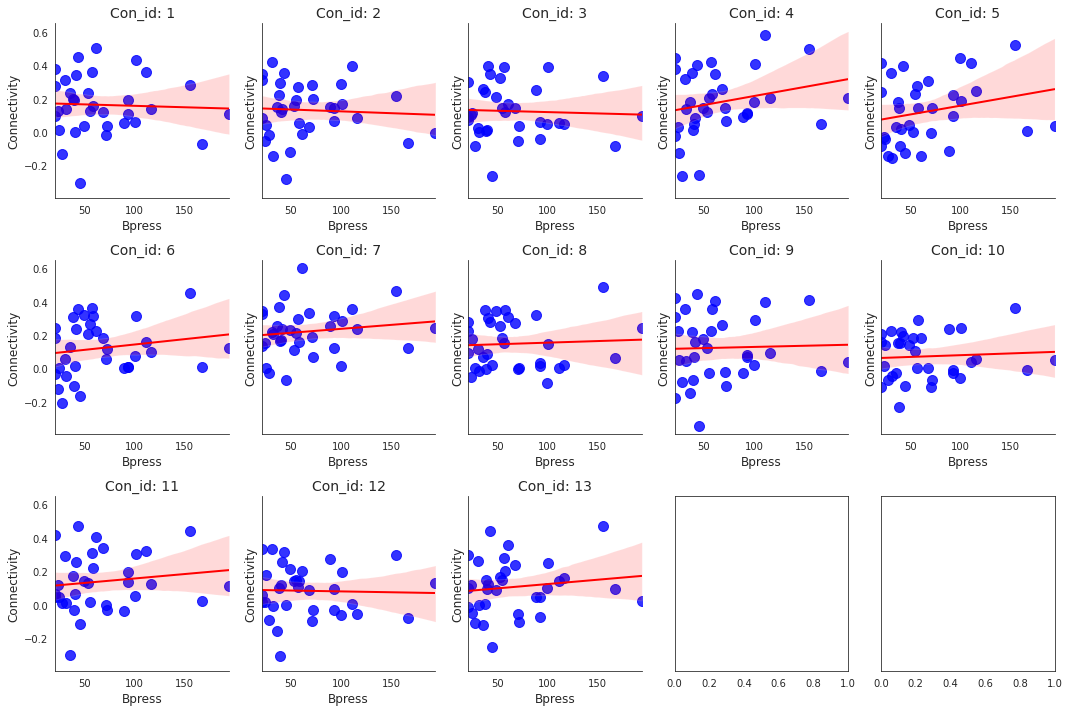

In [98]:
c = 'internal'


# Initialize results dictionary to store connectivity and bpress values
results = {'conn': [], 'bpress': []}

# Set Seaborn style
sns.set_style('white')

# Create subplots with 3 rows and 5 columns (13 total subplots)
fig, axes = plt.subplots(3, 5, figsize=(15, 10), sharey=True)
axes = axes.flatten()  # Flatten the axes array to make indexing easier

# Iterate over the con_id values (assuming 13 different conditions)
for con_id in range(13):
    con_results = {'conn': [], 'bpress': []}
    
    # Iterate over subjects (assuming `wsfc_c` is a dictionary with subjects as keys)
    for s in wsfc_c:
        # Check if the connectivity data is available for the given condition
        try:
            s_mat = wsfc_c[s][c]  # has connectivity data
            bpress_value = bpress[s][c.capitalize()]  # has button press data
        except KeyError:
            print(f"KeyError: {s} or {c.capitalize()} not found in conn or bpress")
            continue

        # Extract the connectivity matrix for the subject
        extracted_values = []
        for row in indices_1:
            for col in indices_2:
                if (row, col) in indices:
                    extracted_values.append(s_mat[row, col])
        
        # Only append the value for the current con_id
        if extracted_values:
            con_results['conn'].append(extracted_values[con_id])
        
        # Append the corresponding bpress value for the subject
        con_results['bpress'].append(bpress_value)
    
    # Convert the results to a DataFrame for easy plotting
    df = pd.DataFrame(con_results)
    
    # Plot using seaborn with a line of fit
    ax = axes[con_id]
    sns.regplot(data=df, x='bpress', y='conn', scatter_kws={'s': 100, 'color': 'blue'}, line_kws={'color': 'red', 'lw': 2}, ax=ax)
    
    # Set the title and labels for the subplot
    ax.set_title(f'Con_id: {con_id + 1}', fontsize=14)
    ax.set_xlabel('Bpress', fontsize=12)
    ax.set_ylabel('Connectivity', fontsize=12)
    
    # Remove spines for cleaner look
    sns.despine(ax=ax)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


KeyError: sub-017 or Internal not found in conn or bpress
KeyError: sub-020 or Internal not found in conn or bpress


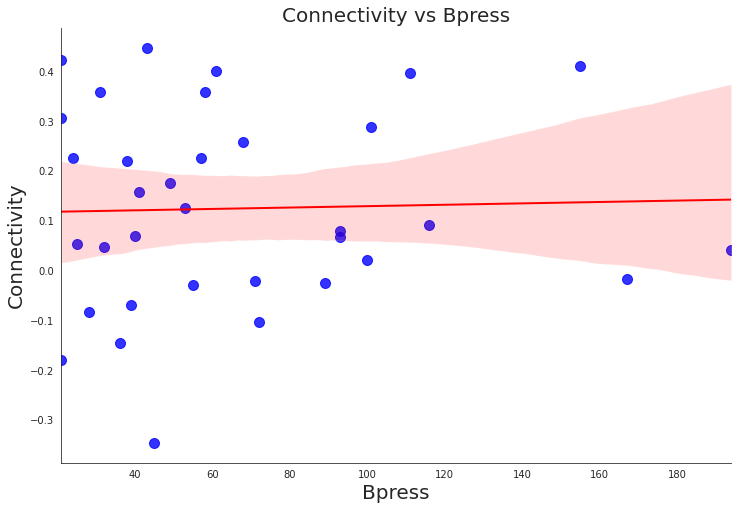

In [99]:
# Initialize results dictionary to store connectivity and bpress values
results = {'conn': [], 'bpress': []}
con_id = 8 ## which con_id to extract from the net

# Iterate over subjects (assuming `wsfc_c` is a dictionary with subjects as keys)
for s in wsfc_c:
    # Check if the connectivity data is available for the given condition
    try:
        s_mat = wsfc_c[s][c]  # has connectivity data
        bpress_value = bpress[s][c.capitalize()]  # has button press data
    except KeyError:
        print(f"KeyError: {s} or {c.capitalize()} not found in conn or bpress")
        continue

    # Extract the connectivity matrix for the subject
    extracted_values = []
    for row in indices_1:
        for col in indices_2:
            if (row, col) in indices:
                extracted_values.append(s_mat[row, col])
    
    # Only append the first extracted value for the subject
    if extracted_values:  # Ensure there are extracted values
        results['conn'].append(extracted_values[con_id])  # Only append the first value
    
    # Append the corresponding bpress value for the subject
    results['bpress'].append(bpress_value)

# Convert the results to a DataFrame for easy plotting
df = pd.DataFrame(results)

# Set Seaborn style
sns.set_style('white')

# Plot using seaborn with a line of fit
plt.figure(figsize=(12, 8))

# Scatterplot with line of fit
sns.regplot(data=df, x='bpress', y='conn', scatter_kws={'s': 100, 'color': 'blue'}, line_kws={'color': 'red', 'lw': 2})

# Title and labels
plt.title('Connectivity vs Bpress', fontsize=20)
plt.xlabel('Bpress', fontsize=20)
plt.ylabel('Connectivity', fontsize=20)

# Remove spines for cleaner look
sns.despine()

plt.show()
